## Bayesian Modelling of Extreme Flows According for Physical-Geographic Features in Vistula Basin

Paweł Jerzyna, Piotr Grzyb

In [2]:
import os
import sys
import glob
import re
from pathlib import Path

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "txt_files"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "csv_files"

sys.path.append(str(PROJECT_ROOT))




# No module named 'nbfomrmat' error - fix this later
#from utils.notebook import run_notebook
#from utils.display import display_df, display_image
"""
ten folder utils jest podjerzany (stworzony przez czat)
jak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki
"""

/home/pawsooon/miniconda3/envs/data_analytics/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'\nten folder utils jest podjerzany (stworzony przez czat)\njak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki\n'

## Czyszczenie danych: Ekstrakcja lat 2023-2025 z surowego datasetu do folderu dataset_cleaned_AAAA

In [3]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Nieznana",
        "Station": "Nieznana",
        "Country": "Nieznany",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Odczyt w kodowaniu 'latin-1' chroni przed błędem crashowania na jednostkach typu km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Przetwarzanie linii nagłówkowych
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Przetwarzanie linii z pomiarami
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Wyciągamy rok i filtrujemy pod kątem lat 2023, 2024, 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # Jeśli stacja nie posiada danych z lat 2023-2025, nie generujemy pliku wyjściowego
    if not data_lines:
        return False
    
    # Budowanie struktury pliku tekstowego z zachowaniem idealnego wyrównania spacji
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Pusta linia oddzielająca metadane od danych
    ]
    
    output_lines.extend(data_lines)
    
    # Zapis w bezpiecznym standardzie UTF-8
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# SZTYWNE USTAWIENIE ŚCIEŻEK - ODPORNE NA CONFIG Z INNYCH KOMÓREK
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned_AAAA"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje!")
else:
    # Tworzenie nowego folderu docelowego
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików pomijając pliki geojson lub inne śmieciowe
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"🚀 Rozpoczynam przetwarzanie... Znaleziono {len(all_files)} plików w folderze '{input_folder.name}'.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Zapis pod dokładnie taką samą nazwą pliku w nowym katalogu
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Błąd w pliku {file_path.name}: {str(e)}")
            
    print("\n" + "="*50)
    print(f"✅ Sukces! Oczyszczono i zapisano: {success} plików.")
    print(f"ℹ️ Pominięto starych stacji:       {skipped} plików.")
    print(f"📁 Wyniki znajdziesz w folderze:    '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam przetwarzanie... Znaleziono 85 plików w folderze 'dataset'.

✅ Sukces! Oczyszczono i zapisano: 69 plików.
ℹ️ Pominięto starych stacji:       16 plików.
📁 Wyniki znajdziesz w folderze:    '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_AAAA'


## Czyszczenie danych: Krok 2 – Konwersja wyekstrahowanych plików TXT do płaskich tabel CSV (Oryginalne nazwy)

In [4]:
# Sztywne ustawienie ścieżek wejścia i wyjścia – niezależne od innych komórek
input_folder = PROJECT_ROOT / "dataset_cleaned_AAAA"
output_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje! Upewnij się, że najpierw uruchomiłeś poprzednią komórkę.")
else:
    # Tworzymy nowy folder na pliki CSV
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików tekstowych z folderu wyekstrahowanego
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"🚀 Rozpoczynam konwersję {len(files)} wyekstrahowanych plików TXT do formatu CSV...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generujemy nową nazwę pliku z rozszerzeniem .csv (np. 6258250_Q_Day.Cmd.csv)
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parsowanie struktury nagłówków tekstowych i wyodrębnienie linii danych
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Przetwarzanie rekordów i budowanie płaskiej struktury tabeli (metadane w każdym wierszu)
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Nieznana"),
                        "Station": metadata.get("Station", "Nieznana"),
                        "Country": metadata.get("Country", "Nieznany"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Zapisujemy do CSV – dane są już przefiltrowane, więc bierzemy cały wyekstrahowany pakiet
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Błąd podczas konwersji pliku {file_path.name}: {str(e)}")
            error_count += 1

    # Końcowy raport operacji
    print("\n" + "="*50)
    print("📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:")
    print(f"   • Konwersja udana (utworzono plików CSV): {success_count}")
    print(f"   • Błędy przetwarzania:                    {error_count}")
    print(f"📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam konwersję 69 wyekstrahowanych plików TXT do formatu CSV...

📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:
   • Konwersja udana (utworzono plików CSV): 69
   • Błędy przetwarzania:                    0
📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_AAA_csv'


## Czyszczenie danych: Krok 3 – Zmiana nazw plików CSV w miejscu (STACJA_RZEKA.csv)

In [5]:
def sanitize_filename(name):
    """Funkcja zamieniająca spacje na myślniki i usuwająca znaki niedozwolone w nazwach plików"""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Sztywne ustawienie folderu docelowego - dokładnie tego, który powstał w Kroku 2
target_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not target_folder.exists():
    print(f"❌ Błąd: Folder z plikami CSV '{target_folder}' nie istnieje! Upewnij się, że poprzednia komórka wykonała się poprawnie.")
else:
    # Zczytujemy listę plików do pamięci jako listę obiektów Path, 
    # aby zmiana nazw w locie nie zaburzyła działania pętli (.glob)
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"🔄 Rozpoczynam zmianę nazw dla {len(csv_files)} plików CSV w folderze '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Czytamy tylko pierwszy wiersz pliku CSV, żeby wyciągnąć metadane (szybkie i oszczędne)
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"⚠️ Pomijam {file_path.name} - brak wymaganych kolumn 'Station' lub 'River'.")
                skipped_count += 1
                continue
            
            # Wyciągamy wartości z pierwszego wiersza
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Czyszczenie nazw stacji i rzek
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Budujemy nową nazwę pliku
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Jeśli nazwa różni się od obecnej, zmieniamy ją fizycznie na dysku
            if file_path != new_path:
                # Zabezpieczenie: jeśli plik o takiej nazwie docelowej już istnieje, usuwamy go przed nadpisaniem
                if new_path.exists():
                    os.remove(new_path)
                
                # Zmiana nazwy w miejscu
                file_path.rename(new_path)
                print(f"✅ Zmieniono: {file_path.name} ➡️ {new_name}")
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"❌ Błąd podczas przetwarzania {file_path.name}: {str(e)}")
            error_count += 1

    print("\n" + "="*50)
    print("📊 PODSUMOWANIE ZMIANY NAZW IN-PLACE:")
    print(f"   • Zmieniono nazw plików:         {renamed_count}")
    print(f"   • Pliki już poprawnie nazwane:   {already_correct_count}")
    print(f"   • Pominięto (błędna struktura):  {skipped_count}")
    print(f"   • Błędy wykonania:               {error_count}")
    print(f"📁 Wszystkie zaktualizowane pliki są w: '{target_folder}'")
    print("="*50)

🔄 Rozpoczynam zmianę nazw dla 138 plików CSV w folderze 'dataset_cleaned_AAA_csv'...
✅ Zmieniono: 6458090_Q_Day.Cmd.csv ➡️ PULAWY-AZOTY_VISTULA.csv
✅ Zmieniono: 6458130_Q_Day.Cmd.csv ➡️ WARSZAWA-NADWILANOWKA_VISTULA.csv
✅ Zmieniono: 6458420_Q_Day.Cmd.csv ➡️ WISLA_VISTULA.csv
✅ Zmieniono: 6458135_Q_Day.Cmd.csv ➡️ ZAMBSKI-KOSCIELNE_NAREV.csv
✅ Zmieniono: 6458030_Q_Day.Cmd.csv ➡️ JELEN_PRZEMSZA.csv
✅ Zmieniono: 6458025_Q_Day.Cmd.csv ➡️ PRZEMYSL_SAN.csv
✅ Zmieniono: 6458200_Q_Day.Cmd.csv ➡️ JORDANOW_SKAWA.csv
✅ Zmieniono: 6458525_Q_Day.Cmd.csv ➡️ NIETULISKO-DUZE_SWISLINA.csv
✅ Zmieniono: 6458809_Q_Day.Cmd.csv ➡️ MYSZYNIEC_ROZOGA.csv
✅ Zmieniono: 6458165_Q_Day.Cmd.csv ➡️ STREKOWA-GORA_NAREV.csv
✅ Zmieniono: 6458020_Q_Day.Cmd.csv ➡️ STARY-SACZ_POPRAD.csv
✅ Zmieniono: 6458620_Q_Day.Cmd.csv ➡️ CISNA_SOLINKA.csv
✅ Zmieniono: 6458120_Q_Day.Cmd.csv ➡️ MODLIN_VISTULA.csv
✅ Zmieniono: 6458150_Q_Day.Cmd.csv ➡️ DOBRYLAS_PISA.csv
✅ Zmieniono: 6458055_Q_Day.Cmd.csv ➡️ MIELEC-2_WISLOKA.csv
✅ Zmieniono: 

## Wizualizacja stacji: Punkty pomiarowe na mapie Polski

In [6]:
import folium
import pandas as pd

csv_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not csv_folder.exists():
    print("❌ Błąd: Folder z plikami CSV nie istnieje!")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Tworzymy bazową mapę wyśrodkowaną na Polskę
    # tiles='OpenStreetMap' pobiera kafelki mapy automatycznie z sieci
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            if lat != -999.000 and lon != -999.000:
                # Treść dymka po kliknięciu w punkt
                popup_text = f"<b>Stacja:</b> {station}<br><b>Rzeka:</b> {river}<br><b>Kraj:</b> {country}"
                
                # Dodajemy punkt na mapę
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"📊 Załadowano {counter} stacji. Wyświetlam interaktywną mapę...")
    # Wyświetlenie mapy bezpośrednio w Jupyter Notebook
    
    # NAPRAWIC !!!
    display(m)

    # Zapisuje mapę jako autonomiczny plik HTML w Twoim folderze projektu
    m.save("mapa_stacji.html")
    print("🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).")


📊 Załadowano 69 stacji. Wyświetlam interaktywną mapę...


🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).


## Analiza eksploracyjna: Wizualizacja szeregu czasowego przepływu dla wybranej stacji (NOWY-SACZ_DUNAJEC)

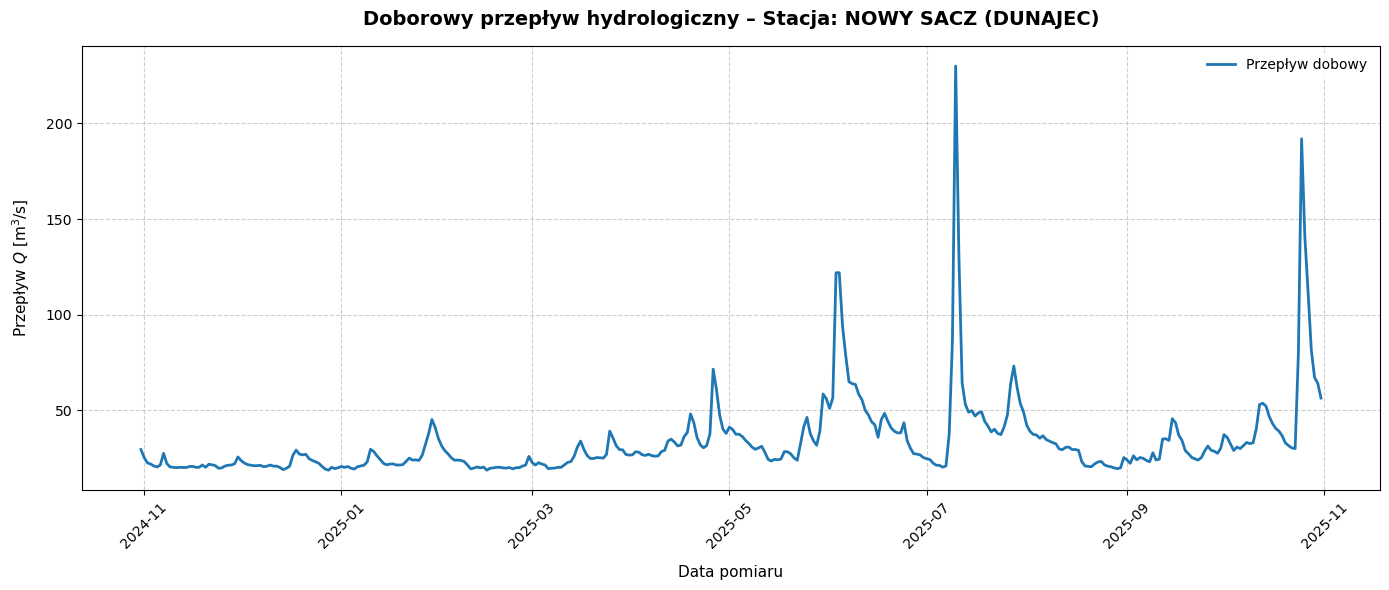

📊 Statystyki przepływu dla okresu 2024-10-31 do 2025-10-31:
   • Maksymalny przepływ (Q_max): 230.000 m³/s
   • Średni przepływ (Q_avg):     33.498 m³/s
   • Minimalny przepływ (Q_min):  18.800 m³/s


In [ ]:
# Ścieżka do folderu z plikami CSV (zdefiniowanego w poprzednich krokach)
csv_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

# Wybierz plik konkretnej stacji, którą chcesz zwizualizować
# Możesz zmienić tę nazwę na dowolny inny plik z folderu
file_name = "NOWY-SACZ_DUNAJEC.csv"
file_path = csv_folder / file_name

if not file_path.exists():
    print(f"❌ Błąd: Plik '{file_path}' nie istnieje! Upewnij się, że nazwa pliku jest poprawna.")
else:
    # 1. Wczytanie danych
    df = pd.read_csv(file_path)
    
    # 2. Konwersja kolumny z datą na format datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # 3. Zabezpieczenie: Zamiana wartości brakujących -999.000 na NaN, aby nie psuły wykresu
    df['Value'] = df['Value'].replace(-999.000, np.nan)
    
    # 4. Filtrowanie danych według zakresu (rok: od 2024-10-31 do 2025-10-31)
    start_date = "2024-10-31"
    end_date = "2025-10-31"
    
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    df_filtered = df.loc[mask].sort_values(by='Date')
    
    if df_filtered.empty:
        print(f"⚠️ Brak danych dla stacji w wybranym okresie od {start_date} do {end_date}.")
    else:
        # Pobranie metadanych z pierwszego wiersza do tytułu wykresu
        station_name = df_filtered['Station'].iloc[0]
        river_name = df_filtered['River'].iloc[0]
        
        # 5. Tworzenie profesjonalnego wykresu szeregu czasowego
        plt.figure(figsize=(14, 6), dpi=100)
        
        plt.plot(df_filtered['Date'], df_filtered['Value'], 
                 color='#1f77b4', linestyle='-', linewidth=2, label='Przepływ dobowy')
        
        # Formatowanie osi i etykiet (użycie LaTeX dla jednostek)
        plt.title(f"Doborowy przepływ hydrologiczny – Stacja: {station_name} ({river_name})", 
                  fontsize=14, weight='bold', pad=15)
        plt.xlabel("Data pomiaru", fontsize=11, labelpad=10)
        plt.ylabel("Przepływ $Q$ [$\\text{m}^3/\\text{s}$]", fontsize=11, labelpad=10)
        
        # Obrócenie dat na osi X dla lepszej czytelności
        plt.xticks(rotation=45)
        
        # Wybór optymalnego wyświetlania siatki
        plt.grid(True, linestyle='--', alpha=0.6, zorder=1)
        plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
        
        # Automatyczne dopasowanie marginesów przed wyświetleniem
        plt.tight_layout()
        plt.show()
        
        # Statystyki opisowe dla wybranego okresu (przydatne przed modelowaniem ekstremów)
        print(f"📊 Statystyki przepływu dla okresu {start_date} do {end_date}:")
        print(f"   • Maksymalny przepływ (Q_max): {df_filtered['Value'].max():.3f} m³/s")
        print(f"   • Średni przepływ (Q_avg):     {df_filtered['Value'].mean():.3f} m³/s")
        print(f"   • Minimalny przepływ (Q_min):  {df_filtered['Value'].min():.3f} m³/s")

## Zbiorcza wizualizacja i porównanie dopływów (Siatka lub Pełne Dorzecze)

🔄 Przetwarzanie i normalizacja wszystkich 69 stacji...


/home/pawsooon/miniconda3/envs/data_analytics/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


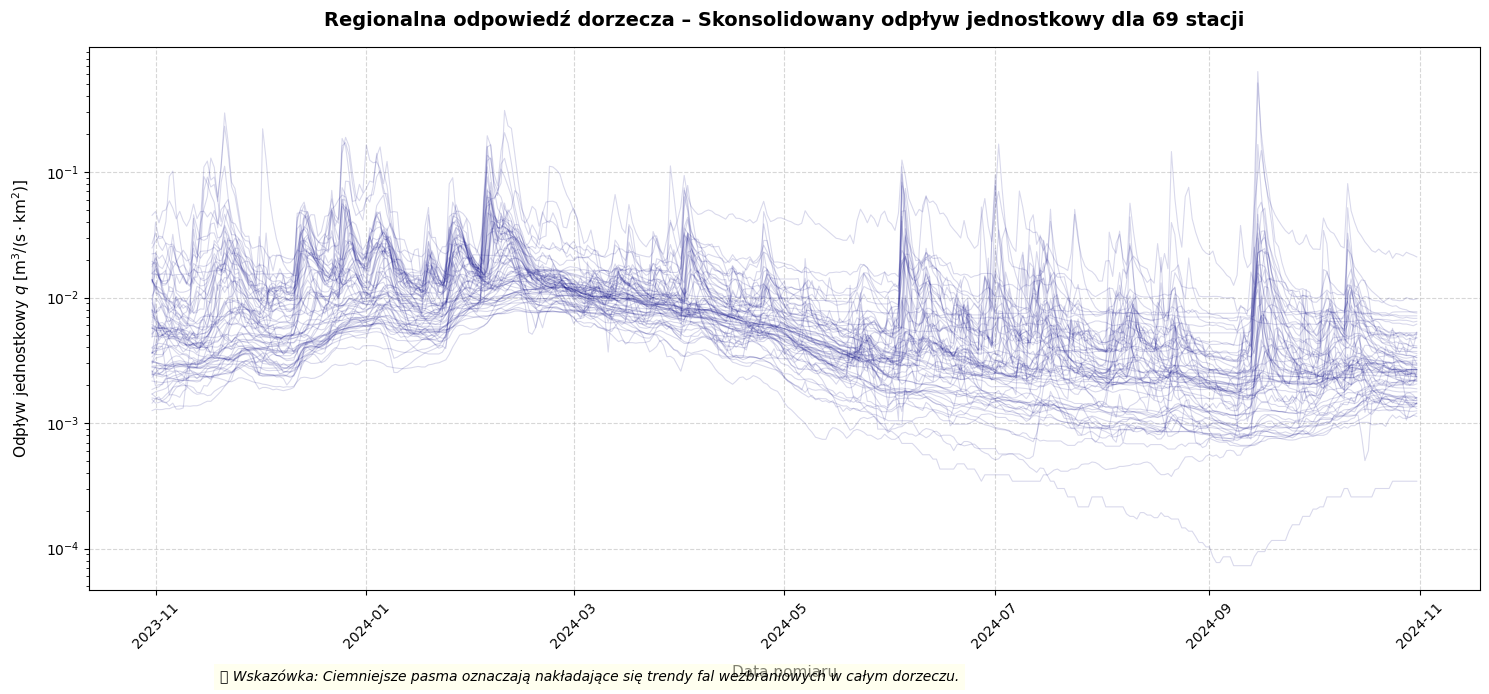

In [10]:
# -------------------------------------------------------------------------
# KONFIGURACJA UŻYTKOWNIKA
# -------------------------------------------------------------------------
# Wybierz tryb działania:
# 'grid' - wyświetla wybrane stacje obok siebie w siatce (idealne do porównań)
# 'all_basin' - wciąga wszystkie 69 stacji na jeden wykres stosując normalizację hydrologiczną
TRYB = 'all_basin' 

# Zakres dat (ten sam co poprzednio)
start_date = "2023-10-31"
end_date = "2024-10-31"

# Lista plików do wyświetlenia w trybie 'grid' (wklej tu dokładne nazwy wygenerowanych plików CSV)
# Możesz dodać 4, 6 lub 9 plików - skrypt sam dopasuje układ siatki
wybrane_pliki = [
    "NOWY-SACZ_DUNAJEC.csv",
    "BIALOBRZEGI_PILICA.csv",     
    "BOCHENIEC_LOSOSNA.csv",
    "BORKOWO_WKRA.csv",
    "BRODNICA_DRWECA.csv",
    "PULAWY-AZOTY_VISTULA.csv",
]
# -------------------------------------------------------------------------

csv_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"
all_csv_files = list(csv_folder.glob('*.csv'))

if not csv_folder.exists() or len(all_csv_files) == 0:
    print(f"❌ Błąd: Folder '{csv_folder}' nie istnieje lub jest pusty!")
else:
    # --------------------------------
    # OPZJA 1: SIATKA WYKRESÓW (GRID)
    # --------------------------------
    if TRYB == 'grid':
        # Jeśli lista użytkownika jest pusta, weź pierwsze dostępne pliki jako fallback
        pliki_do_weryfikacji = wybrane_pliki if len(wybrane_pliki) > 0 else [f.name for f in all_csv_files[:4]]
        
        # Filtrowanie tylko istniejących plików
        dostepne_pliki = [f for f in pliki_do_weryfikacji if (csv_folder / f).exists()]
        
        n_plots = len(dostepne_pliki)
        if n_plots == 0:
            print("❌ Brak pasujących plików z listy do wyświetlenia w siatce.")
        else:
            # Dynamiczne wyliczanie wierszy i kolumn dla siatki (maksymalnie 3 kolumny)
            n_cols = 2 if n_plots <= 4 else 3
            n_rows = (n_plots + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex=True, dpi=100)
            axes = np.array(axes).flatten() # Spłaszczenie macierzy osi do 1D dla łatwiejszej pętli
            
            for idx, f_name in enumerate(dostepne_pliki):
                ax = axes[idx]
                df = pd.read_csv(csv_folder / f_name)
                df['Date'] = pd.to_datetime(df['Date'])
                df['Value'] = df['Value'].replace(-999.000, np.nan)
                
                df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].sort_values('Date')
                
                if not df_filtered.empty:
                    ax.plot(df_filtered['Date'], df_filtered['Value'], color=plt.cm.tab10(idx % 10), linewidth=1.8)
                    ax.set_title(f"{df_filtered['Station'].iloc[0]} ({df_filtered['River'].iloc[0]})", fontsize=11, weight='bold')
                    ax.grid(True, linestyle='--', alpha=0.5)
                    ax.tick_params(axis='x', rotation=35)
                    if idx % n_cols == 0:
                        ax.set_ylabel("$Q$ [$\\text{m}^3/\\text{s}$]")
            
            # Ukrycie niewykorzystanych okienek wykresu w siatce
            for j in range(idx + 1, len(axes)):
                fig.delaxes(axes[j])
                
            fig.suptitle(f"Porównanie przepływów w wybranych stacjach ({start_date} do {end_date})", fontsize=14, weight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

    # --------------------------------
    # OPCJA 2: PEŁNE DORZECZE (ALL)
    # --------------------------------
    elif TRYB == 'all_basin':
        plt.figure(figsize=(15, 7), dpi=100)
        loaded_count = 0
        
        print(f"🔄 Przetwarzanie i normalizacja wszystkich {len(all_csv_files)} stacji...")
        
        for file_path in all_csv_files:
            try:
                df = pd.read_csv(file_path)
                df['Date'] = pd.to_datetime(df['Date'])
                df['Value'] = df['Value'].replace(-999.000, np.nan)
                
                df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].sort_values('Date')
                
                if not df_filtered.empty:
                    catchment = float(df_filtered['Catchment_area_km2'].iloc[0])
                    
                    # Warunek hydrologiczny: Jeśli pole zlewni jest nieznane lub błędne (-999), pomijamy
                    if catchment > 0:
                        # Normalizacja: dzielimy przepływ przez powierzchnię zlewni.
                        # Daje to odpływ jednostkowy q [m3 / (s * km2)]
                        normalized_flow = df_filtered['Value'] / catchment
                        
                        plt.plot(df_filtered['Date'], normalized_flow, color='navy', alpha=0.15, linewidth=0.8, zorder=2)
                        loaded_count += 1
            except:
                pass # Pomiń pliki, które mogłyby być uszkodzone strukturalnie
                
        if loaded_count > 0:
            plt.title(f"Regionalna odpowiedź dorzecza – Skonsolidowany odpływ jednostkowy dla {loaded_count} stacji", fontsize=14, weight='bold', pad=15)
            plt.xlabel("Data pomiaru", fontsize=11, labelpad=10)
            # Jednostka odpływu jednostkowego we współczesnej hydrologii
            plt.ylabel("Odpływ jednostkowy $q$ [$\\text{m}^3 / (\\text{s} \\cdot \\text{km}^2)$]", fontsize=11, labelpad=10)
            plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
            plt.xticks(rotation=45)
            
            # Skala logarytmiczna chroni wykres, gdyby któraś stacja miała gigantyczną anomalię/błąd pomiarowy
            plt.yscale('log')
            plt.figtext(0.15, 0.02, "💡 Wskazówka: Ciemniejsze pasma oznaczają nakładające się trendy fal wezbraniowych w całym dorzeczu.", fontsize=10, style='italic', bbox=dict(facecolor='lightyellow', alpha=0.5, edgecolor='none'))
            
            plt.tight_layout()
            plt.show()
        else:
            print("❌ Nie udało się załadować żadnej stacji z poprawną powierzchnią zlewni.")

# Modele

Bayesowskie pożyczanie siły to jest nasz główny keirunek.

Prostszy model to Hierarchiczny GEV (Generalized Extreme Value) ze stałymi parametrami (Partial Pooling). Wyciągane są maksima roczne dla każdej stacji z domysłem struktury hierarchicznej, ale bez patrzenia na cechy fizyczno-geograficzne. Model uczy się charakterystyki dorzecza jako całości.

**Matematyka ogona:**
Maksima roczne $Y_{s,t}$ dla stacji $s$ i roku $t$ podlegają uogólnionemu rozkładowi wartości ekstremalnych (GEV):

$$Y_{s,t} \sim \text{GEV}(\mu_s, \sigma_s, \xi)$$

---

**Struktura hierarchiczna typu *Centered*:**
Parametry lokalizacji ($\mu_s$) oraz skali ($\sigma_s$) dla każdej poszczególnej stacji są losowane wokół wspólnej średniej wyznaczonej hierarchicznie dla całego dorzecza:

$$\mu_s \sim \text{Normal}(\bar{\mu}, \tau_{\mu})$$

$$\sigma_s \sim \text{LogNormal}(\bar{\sigma}, \tau_{\sigma})$$

---

**Parametr kształtu ($\xi$):**
Jest stały i współdzielony dla wszystkich 69 stacji (*complete pooling*). Ze względu na to, że oszacowanie parametru kształtu ogona rozkładu na poziomie lokalnym przy zaledwie 3-letniej serii danych jest obarczone krytycznym błędem matematycznym, model agreguje informacje i uczy się geometrii ogona globalnie dla całego ekosystemu rzek.

## Model 1: Prior Predictive Check (Symulacja a priori bez danych)

## UWAGA NIEKTORE STACEJ MAJA TYLKO 2 LATA OBSERWACJI (2023-2024), A NIE TRZY! TRZEBA TO BEDIZE GDZIES UWZGLEDNIC!

00:32:31 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_prior.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_prior


⏳ Kompilacja modelu Stan... (to może chwilę potrwać)


00:32:45 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_prior
00:32:45 - cmdstanpy - INFO - CmdStan start processing


✅ Model skompilowany pomyślnie!

🚀 Uruchamiam Prior Predictive Simulation...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]





chain 1:   7%|▋         | 100/1500 [00:00<00:02, 494.76it/s, (Warmup)]


chain 1:  33%|███▎      | 500/1500 [00:00<00:00, 1717.97it/s, (Warmup)]



chain 1:  53%|█████▎    | 800/1500 [00:00<00:00, 2027.03it/s, (Warmup)]




chain 1:  73%|███████▎  | 1100/1500 [00:00<00:00, 1668.12it/s, (Sampling)]

chain 2: 100%|██████████| 1500/1500 [00:00<00:00, 1722.71it/s, (Sampling completed)]

chain 3: 100%|██████████| 1500/1500 [00:00<00:00, 1720.14it/s, (Sampling completed)]


chain 4: 100%|██████████| 1500/1500 [00:00<00:00, 1718.57it/s, (Sampling completed)]


00:32:46 - cmdstanpy - INFO - CmdStan done processing.
00:32:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter is 0, but must be positive finite! (in 'model1_prior.stan', line 41, column 2 to column 42)
Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model1_prior.stan', line 41, column 2 to column 42)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model1_prior.stan', line 41, column 2 to column 42)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'model1_prior.stan', line 41, column 2 to column 42)
Consider re-running with show_console=True if the above output is unclear!
00:32:46 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 73 divergent transitions (14.6%)
	Chain 1 had 2 iterations at max treedepth (0.4%)
	Chain 2 had 8 divergent transitions (1.6%)
	Chain 2 had 1 iterations at max treedept

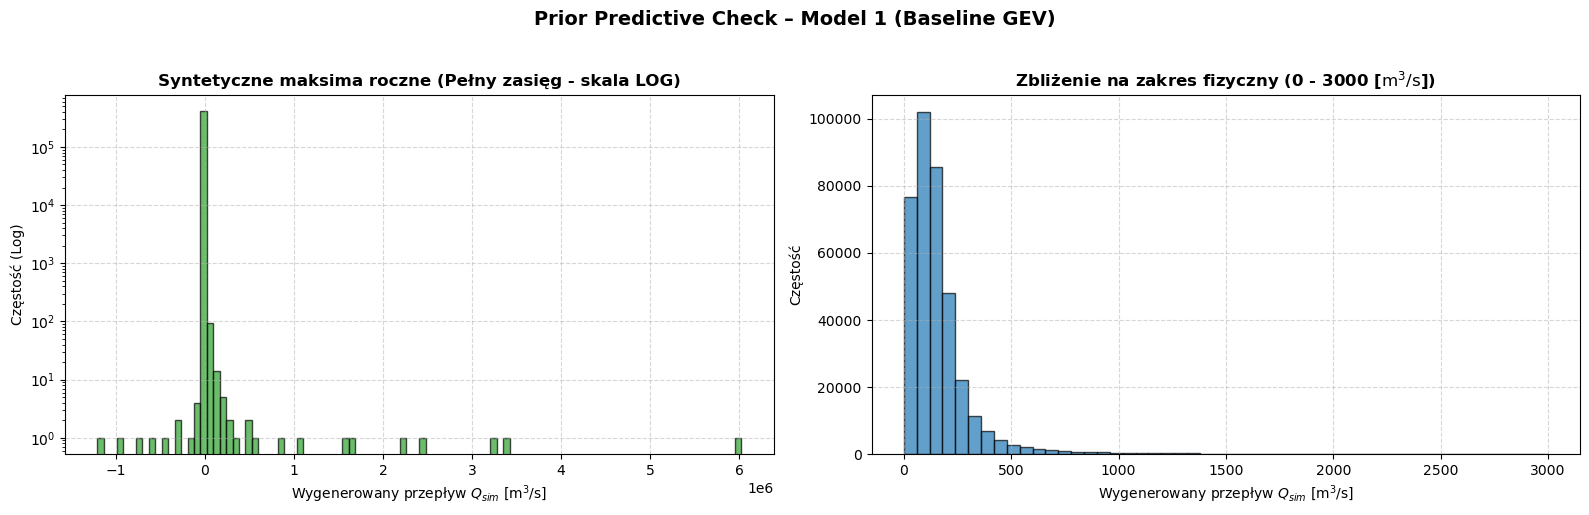


📊 RAPORT PRIOR PREDICTIVE CHECK:
   • Łączna liczba wygenerowanych maksimów: 414000
   • Procent wygenerowanych ujemnych wartości: 10.01%
   • Mediana wygenerowanych maksimów:       112.08 m³/s
   • 95. percentyl przepływu w PPC:         409.59 m³/s


In [16]:
# 1. Definicja ścieżki do pliku Stan (dostosuj jeśli masz inną strukturę folderów)
stan_file = SCRIPTS_DIR / "stan" / "model1_prior.stan"

# Symulujemy strukturę Twojego oczyszczonego datasetu
# Pamiętaj: W Prior Predictive Check NIE przekazujemy realnych pomiarów rzek!
S_stations = 69
T_years = 3

stan_data = {
    "S": S_stations,
    "T": T_years
}

if not stan_file.exists():
    print(f"❌ Błąd: Plik modelu Stan nie istnieje pod ścieżką: {stan_file}")
else:
    # 2. Kompilacja modelu w Stan
    print("⏳ Kompilacja modelu Stan... (to może chwilę potrwać)")
    model = CmdStanModel(stan_file=str(stan_file))
    print("✅ Model skompilowany pomyślnie!")
    
    # 3. Próbkowanie wyłącznie z rozkładów a priori
    # Ponieważ w sekcji 'model' są tylko priory, a danych 'y' nie ma w likelihood,
    # Stan po prostu wylosuje niezależne parametry i wygeneruje 'y_sim'.
    print("\n🚀 Uruchamiam Prior Predictive Simulation...")
    prior_sample = model.sample(
        data=stan_data,
        chains=4,
        iter_sampling=500,  # 500 próbek na 1 łańcuch wystarczy do PPC
        show_progress=True
    )
    
    # 4. Konwersja wyników do formatu ArviZ InferenceData
    idata = az.from_cmdstanpy(prior=prior_sample, prior_predictive=["y_sim"])
    
    # 5. Ekstrakcja wygenerowanych syntetycznych przepływów
    # Rezultat ma wymiary: [łańcuchy * próbki, stacje, lata]
    y_sim_raw = idata.prior_predictive["y_sim"].values
    y_sim_flat = y_sim_raw.flatten()
    
    # Odrzucamy ewentualne ekstremalne wartości nieskończone, gdyby ogon wyskoczył za daleko
    y_sim_flat = y_sim_flat[np.isfinite(y_sim_flat)]
    
    # 6. Wizualizacja rozkładu a priori przepływów ekstremalnych
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
    
    # Wykres 1: Pełny rozkład (skala logarytmiczna dla ogona)
    ax1.hist(y_sim_flat, bins=100, color='#2ca02c', edgecolor='black', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title("Syntetyczne maksima roczne (Pełny zasięg - skala LOG)", fontsize=12, weight='bold')
    ax1.set_xlabel("Wygenerowany przepływ $Q_{sim}$ [$\\text{m}^3/\\text{s}$]")
    ax1.set_ylabel("Częstość (Log)")
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 2: Zoom na fizycznie prawdopodobny zakres (0 do 3000 m3/s)
    # Pozwala ocenić, czy większość masy prawdopodobieństwa leży w rozsądnych granicach
    zoom_range = y_sim_flat[(y_sim_flat >= 0) & (y_sim_flat <= 3000)]
    ax2.hist(zoom_range, bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)
    ax2.set_title("Zbliżenie na zakres fizyczny (0 - 3000 [$\\text{m}^3/\\text{s}$])", fontsize=12, weight='bold')
    ax2.set_xlabel("Wygenerowany przepływ $Q_{sim}$ [$\\text{m}^3/\\text{s}$]")
    ax2.set_ylabel("Częstość")
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    fig.suptitle("Prior Predictive Check – Model 1 (Baseline GEV)", fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Krótki raport statystyczny z symulacji
    print("\n" + "="*50)
    print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
    print(f"   • Łączna liczba wygenerowanych maksimów: {len(y_sim_flat)}")
    print(f"   • Procent wygenerowanych ujemnych wartości: {(y_sim_flat < 0).mean()*100:.2f}%")
    print(f"   • Mediana wygenerowanych maksimów:       {np.median(y_sim_flat):.2f} m³/s")
    print(f"   • 95. percentyl przepływu w PPC:         {np.percentile(y_sim_flat, 95):.2f} m³/s")
    print("="*50)

# ROZKŁAD A POSTERIORI

## Czyszczenie danych: Krok 4 – Wyznaczanie maksimów rocznych (Block Maxima) do formatu długiego

In [17]:
csv_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"
all_csv_files = sorted(list(csv_folder.glob('*.csv')))

if not csv_folder.exists() or len(all_csv_files) == 0:
    print(f"❌ Błąd: Folder '{csv_folder}' nie istnieje lub jest pusty!")
else:
    block_maxima_data = []
    
    # Słownik do mapowania unikalnych nazw stacji na ID od 1 do S
    station_to_id = {}
    station_counter = 1
    
    # Metadane stacji potrzebne do późniejszego Modelu 2 (złożonego)
    station_features = {}

    for file_path in all_csv_files:
        df = pd.read_csv(file_path)
        
        # Pobieramy unikalny klucz stacji
        station_name = df['Station'].iloc[0]
        river_name = df['River'].iloc[0]
        station_key = f"{station_name}_{river_name}"
        
        if station_key not in station_to_id:
            station_to_id[station_key] = station_counter
            
            # Pobranie cech fizyczno-geograficznych stacji
            catchment = float(df['Catchment_area_km2'].iloc[0])
            altitude = float(df['Altitude_m_ASL'].iloc[0])
            
            station_features[station_counter] = {
                'catchment': catchment if catchment > 0 else 100.0, # fallback
                'altitude': altitude if altitude != -999.00 else 100.0
            }
            station_counter += 1
            
        current_id = station_to_id[station_key]
        
        # Konwersja dat i czyszczenie braków
        df['Date'] = pd.to_datetime(df['Date'])
        df['Value'] = df['Value'].replace(-999.000, np.nan)
        df['Year'] = df['Date'].dt.year
        
        # Agregacja: wyciągamy maksimum dla każdego roku pomiarowego
        annual_max = df.groupby('Year')['Value'].max().dropna().reset_index()
        
        for _, row in annual_max.iterrows():
            block_maxima_data.append({
                'station_id': current_id,
                'year': int(row['Year']),
                'max_flow': float(row['Value'])
            })

    # Tworzymy końcowy DataFrame
    df_bm = pd.DataFrame(block_maxima_data)
    
    # Przygotowanie słownika danych bezpośrednio wejściowych do CmdStanPy
    stan_data = {
        'N': len(df_bm),
        'S': len(station_to_id),
        'y': df_bm['max_flow'].values,
        'station_id': df_bm['station_id'].values
    }
    
    print("="*50)
    print("📊 PRZYGOTOWANIE DANYCH DO MODELU ZAKOŃCZONE:")
    print(f"   • Łączna liczba stacji (S):             {stan_data['S']}")
    print(f"   • Łączna liczba punktów danych (N):     {stan_data['N']}")
    print(f"   • Średnia liczba lat na stację:        {stan_data['N']/stan_data['S']:.2f}")
    print("="*50)

📊 PRZYGOTOWANIE DANYCH DO MODELU ZAKOŃCZONE:
   • Łączna liczba stacji (S):             69
   • Łączna liczba punktów danych (N):     156
   • Średnia liczba lat na stację:        2.26


## Model 1: Próbkowanie MCMC (Dopasowanie modelu do danych historycznych)

In [ ]:
stan_fit_file = SCRIPTS_DIR / "stan" / "model1_fit.stan"

if not stan_fit_file.exists():
    print(f"❌ Błąd: Plik '{stan_fit_file}' nie istnieje!")
else:
    print("⏳ Kompilacja modelu produkcyjnego GEV... (to może chwilę potrwać)")
    model_fit = CmdStanModel(stan_file=str(stan_fit_file))
    
    print("\n🚀 Uruchamiam próbkowanie MCMC (4 łańcuchy)...")
    # Przekazujemy realny słownik stan_data przygotowany w Komórce 1
    fit = model_fit.sample(
        data=stan_data,
        chains=4,
        iter_warmup=1000,
        iter_sampling=1000,
        seed=42,
        show_progress=True
    )
    
    # Konwersja wyników do formatu ArviZ
    idata_fit = az.from_cmdstanpy(
        posterior=fit,
        posterior_predictive=["y_rep"],
        observed_data={"y": stan_data['y']}
    )
    
    print("\n" + "="*50)
    print("✅ PRÓBKOWANIE ZAKOŃCZONE!")
    # Wyświetlamy podstawową diagnostykę zbieżności
    summary = az.summary(idata_fit, var_names=["bar_mu", "tau_mu", "bar_sigma", "tau_sigma", "xi"])
    print("\n📊 GŁÓWNE PARAMETRY MODELU (HIERARCHIA GLOBALNA):")
    # Wyświetlamy cały obiekt summary, bez ręcznego wycinania kolumn, co zapobiega KeyError
    display(summary) 
    print("="*50)

00:48:29 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_fit.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_fit


⏳ Kompilacja modelu produkcyjnego GEV... (to może chwilę potrwać)


00:48:43 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/model1_fit
00:48:43 - cmdstanpy - INFO - CmdStan start processing



🚀 Uruchamiam próbkowanie MCMC (4 łańcuchy)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:  55%|█████▌    | 1100/2000 [00:00<00:00, 9947.90it/s, (Sampling)] 











chain 2: 100%|██████████| 2000/2000 [00:02<00:00, 975.36it/s, (Sampling completed)] 

chain 3: 100%|██████████| 2000/2000 [00:02<00:00, 974.97it/s, (Sampling completed)] 


chain 4: 100%|██████████| 2000/2000 [00:02<00:00, 974.14it/s, (Sampling completed)] 


00:48:45 - cmdstanpy - INFO - CmdStan done processing.
00:48:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: model1_fit_model_namespace::log_prob: sigma[1] is -nan, but must be greater than or equal to 0.000000 (in 'model1_fit.stan', line 23, column 2 to column 27)
	Exception: model1_fit_model_namespace::log_prob: sigma[1] is -nan, but must be greater than or equal to 0.000000 (in 'model1_fit.stan', line 23, column 2 to column 27)
	Exception: model1_fit_model_namespace::log_prob: sigma[1] is -nan, but must be greater than or equal to 0.000000 (in 'model1_fit.stan', line 23, column 2 to column 27)
	Exception: model1_fit_model_namespace::log_prob: sigma[1] is -nan, but must be greater than or equal to 0.000000 (in 'model1_fit.stan', line 23, column 2 to column 27)
	Exception: model1_fit_model_namespace::log_prob: sigma[1] is -nan, but must be greater than or equal to 0.000000 (in 'model1_fit.stan', line 23, column 2 to column 27)
	Exception: model1_fit_model_names

/home/pawsooon/miniconda3/envs/data_analytics/lib/python3.14/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



✅ PRÓBKOWANIE ZAKOŃCZONE!

📊 GŁÓWNE PARAMETRY MODELU (HIERARCHIA GLOBALNA):


KeyError: "['hdi_3%', 'hdi_97%'] not in index"